# Class 9. Hybrid Quantum-Classical Neural Networks (Solutions)

EVA: Quantum Machine Learning | ZHAW | Pavel Sulimov

---

Goals of this practice session:

1. Compute expectation values and forward passes of a hybrid QNN by hand.
2. Verify the parameter-shift gradient rule on a single gate.
3. Build and train a `TorchLayer`-based hybrid model from scratch.
4. Compare re-uploading vs single-pass encoding on a non-linearly separable dataset.
5. Implement a C-Q-C model and evaluate it against a classical baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import pennylane as qml
from pennylane import numpy as pnp
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

---
## Conceptual notes for this session

Qubits start in $\lvert 0\rangle$ by default. A hybrid quantum-classical model
has the general form

$$
\hat{y} = g\!\left(\langle O_1\rangle, \ldots, \langle O_m\rangle;\, \psi\right),
\quad
\langle O_k\rangle = \bra{\psi(x,\theta)} O_k \ket{\psi(x,\theta)},
\quad
\ket{\psi(x,\theta)} = U_{\text{ans}}(\theta)\, U_{\text{enc}}(x)\ket{0}^{\otimes n}.
$$

The encoding layer $U_{\text{enc}}(x)$ injects classical data into the circuit
(no trainable parameters). The ansatz $U_{\text{ans}}(\theta)$ contains the trainable
rotation angles. The classical function $g$ (e.g. a linear head + sigmoid) maps
the measured expectation values to the final prediction.

The parameter-shift rule computes exact gradients of expectation values:

$$
\frac{\partial}{\partial \theta_k}\langle O\rangle(\theta)
= \frac{1}{2}\bigl[
  \langle O\rangle\!\left(\theta_k + \tfrac{\pi}{2}\right)
  - \langle O\rangle\!\left(\theta_k - \tfrac{\pi}{2}\right)
\bigr].
$$

In PennyLane, `TorchLayer` wraps a `QNode` into a standard `nn.Module`.
Gradient computation is handled automatically; the training loop is identical
to any classical PyTorch model.

---
## Part 1: Math tasks

### M9.1. Forward pass of a one-qubit hybrid model

Consider a one-qubit circuit with one trainable parameter $\theta$:

$$
\ket{\psi(x, \theta)} = R_y(\theta)\, R_y(\pi x)\ket{0},
\quad x = 0.5,\quad \theta = \frac{\pi}{4}.
$$

Compute:
1. the state $\ket{\psi(x, \theta)}$ in the computational basis
2. the expectation value $\langle Z\rangle$
3. the predicted probability $\hat{p} = \sigma(\langle Z\rangle)$ where $\sigma$ is the sigmoid

In [2]:
x = 0.5
theta = np.pi / 4

# R_y(phi)|0> = cos(phi/2)|0> + sin(phi/2)|1>
# Composed: R_y(theta) * R_y(pi*x) = R_y(theta + pi*x) because R_y rotations compose additively
total_angle = theta + np.pi * x

alpha = np.cos(total_angle / 2)
beta  = np.sin(total_angle / 2)

psi = np.array([alpha, beta], dtype=complex)

# <Z> = |alpha|^2 - |beta|^2
exp_Z = np.abs(alpha)**2 - np.abs(beta)**2

# sigmoid
sigmoid = lambda z: 1.0 / (1.0 + np.exp(-z))
p_hat = sigmoid(exp_Z)

print(f"Total rotation angle: {total_angle:.6f} rad")
print(f"State: {alpha:.6f}|0> + {beta:.6f}|1>")
print(f"<Z> = {exp_Z:.6f}")
print(f"sigma(<Z>) = {p_hat:.6f}")

Total rotation angle: 2.356194 rad
State: 0.382683|0> + 0.923880|1>
<Z> = -0.707107
sigma(<Z>) = 0.330238


In [3]:
# Cross-check with Qiskit
qc = QuantumCircuit(1)
qc.ry(np.pi * x, 0)   # encoding
qc.ry(theta, 0)        # ansatz

sv = Statevector(qc)
exp_Z_qiskit = sv.expectation_value(qml.matrix(qml.PauliZ)(0) if False
               else np.diag([1, -1])).real

print(f"Qiskit statevector: {np.round(sv.data, 6)}")
print(f"<Z> from Qiskit:    {exp_Z_qiskit:.6f}")
print(f"Match: {np.isclose(exp_Z, exp_Z_qiskit)}")

Qiskit statevector: [0.382683+0.j 0.92388 +0.j]
<Z> from Qiskit:    -0.707107
Match: True


### M9.2. Parameter-shift gradient verification

For the circuit $\langle Z\rangle(\theta) = \bra{0}R_y^\dagger(\pi x + \theta)\, Z\, R_y(\pi x + \theta)\ket{0}$
with $x = 0.5$:

1. Compute the gradient $\frac{d}{d\theta}\langle Z\rangle$ at $\theta = \pi/4$ analytically.
2. Verify using the parameter-shift rule: $\frac{d}{d\theta}\langle Z\rangle \approx
   \frac{1}{2}[\langle Z\rangle(\theta + \pi/2) - \langle Z\rangle(\theta - \pi/2)]$.

In [4]:
def expval_Z_ry(theta_val, x_val=0.5):
    """<Z> for single R_y(pi*x) R_y(theta) circuit."""
    phi = np.pi * x_val + theta_val
    return np.cos(phi)  # <Z> = cos(phi) for R_y(phi)|0>


theta0 = np.pi / 4
shift  = np.pi / 2

# Analytical gradient: d/dtheta cos(pi*x + theta) = -sin(pi*x + theta)
grad_analytical = -np.sin(np.pi * x + theta0)

# Parameter-shift
grad_shift = 0.5 * (expval_Z_ry(theta0 + shift) - expval_Z_ry(theta0 - shift))

print(f"Analytical gradient:      {grad_analytical:.8f}")
print(f"Parameter-shift gradient: {grad_shift:.8f}")
print(f"Match: {np.isclose(grad_analytical, grad_shift)}")

Analytical gradient:      -0.70710678
Parameter-shift gradient: -0.70710678
Match: True


### M9.3. Architecture pattern identification

Identify which hybrid architecture pattern (Q-C, C-Q, C-Q-C, Q-C-Q-C) is
described in each scenario:

a) A ResNet-50 extracts a 256-dim embedding from an image. That embedding is
   reduced to 4 dimensions with a linear layer, then fed into a 4-qubit PQC.
   The single expectation value $\langle Z_0\rangle$ is the model output.

b) A 6-qubit VQC produces 6 expectation values which are passed to a
   `Linear(6, 10)` + softmax for 10-class classification.

c) A 2-qubit circuit produces $\langle Z_0\rangle$, which is processed by a
   small `Linear(1, 4) + ReLU`, whose output feeds a second 4-qubit circuit,
   followed by a final sigmoid.

**Answers:**

a) C-Q: a classical block (ResNet + Linear) precedes the quantum circuit with no classical post-processing after the quantum output.

b) Q-C: the quantum circuit is first; the classical head maps the measured observables to class logits.

c) Q-C-Q-C (alternating): quantum $\to$ classical $\to$ quantum $\to$ classical, with two quantum-classical boundaries.

---
## Part 2: Programming tasks

### P9.1. Build and inspect a TorchLayer hybrid model

Define a 2-qubit QNode using `AngleEmbedding` + `StronglyEntanglingLayers`.
Wrap it in a `TorchLayer` and compose a Q-C model.
Run a forward pass on a batch of 4 samples and print the output shape and values.

In [5]:
n_qubits = 2
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev, interface="torch", diff_method="backprop")
def circuit_p1(inputs, weights):
    """2-qubit circuit: AngleEmbedding + StronglyEntanglingLayers.

    Args:
        inputs: shape (2,) -- features scaled to [0, 1]
        weights: shape (n_layers, 2, 3)

    Returns:
        Expectation value <Z_0>.
    """
    qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))


qlayer_p1 = qml.qnn.TorchLayer(circuit_p1, {"weights": (n_layers, n_qubits, 3)})

model_p1 = nn.Sequential(
    qlayer_p1,
    nn.Sigmoid(),
)

x_batch = torch.rand(4, n_qubits)
with torch.no_grad():
    out = model_p1(x_batch)

print("Input shape: ", x_batch.shape)
print("Output shape:", out.shape)
print("Output values (raw sigmoid output):", out.numpy().ravel())

Input shape:  torch.Size([4, 2])
Output shape: torch.Size([4])
Output values (raw sigmoid output): [0.34378514 0.3293117  0.54752564 0.31078774]


### P9.2. Train Q-C and C-Q-C models on moons; compare with logistic regression

Generate the moons dataset (150 train, 50 test), scale features to $[0,1]$,
then train:

1. Q-C model: `circuit_p1 + Sigmoid`
2. C-Q-C model: `Linear(2,2)+Tanh -> quantum (multi-output) -> Linear(2,1)+Sigmoid`
3. Logistic regression baseline

Report test accuracy for all three.

In [6]:
# Data preparation
X_raw, y_raw = make_moons(n_samples=200, noise=0.25, random_state=1)
X_sc = MinMaxScaler().fit_transform(X_raw)
X_tr, X_te, y_tr, y_te = train_test_split(X_sc, y_raw, test_size=0.25, random_state=1)

X_train = torch.tensor(X_tr, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.float32)
X_test  = torch.tensor(X_te, dtype=torch.float32)


def train_binary(model, X_train, y_train, n_epochs=80, lr=0.02):
    """Standard binary classification training loop."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.BCELoss()
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        preds = model(X_train).squeeze()
        loss  = loss_fn(preds, y_train)
        loss.backward()
        optimizer.step()
    return model


# Q-C model (already defined above, re-instantiate for fresh weights)
ql_qc = qml.qnn.TorchLayer(circuit_p1, {"weights": (n_layers, n_qubits, 3)})
model_qc_p2 = nn.Sequential(ql_qc, nn.Sigmoid())
train_binary(model_qc_p2, X_train, y_train)
with torch.no_grad():
    acc_qc = accuracy_score(y_te, (model_qc_p2(X_test).squeeze().numpy() >= 0.5))


# Multi-output circuit for C-Q-C
@qml.qnode(dev, interface="torch", diff_method="backprop")
def circuit_multi(inputs, weights):
    """Returns <Z> on each qubit."""
    qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class CQC_P2(nn.Module):
    """C-Q-C hybrid model."""

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(2, n_qubits), nn.Tanh())
        self.qnode   = qml.qnn.TorchLayer(circuit_multi, {"weights": (n_layers, n_qubits, 3)})
        self.head    = nn.Sequential(nn.Linear(n_qubits, 1), nn.Sigmoid())

    def forward(self, x):
        x = (self.encoder(x) + 1.0) / 2.0  # tanh -> [0, 1]
        x = self.qnode(x)
        return self.head(x)


model_cqc_p2 = CQC_P2()
train_binary(model_cqc_p2, X_train, y_train)
with torch.no_grad():
    acc_cqc = accuracy_score(y_te, (model_cqc_p2(X_test).squeeze().numpy() >= 0.5))

# Classical baseline
lr_clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
acc_lr = lr_clf.score(X_te, y_te)

print("Results on moons (noise=0.25):")
print(f"  Logistic regression: {acc_lr:.3f}")
print(f"  Q-C model:           {acc_qc:.3f}")
print(f"  C-Q-C model:         {acc_cqc:.3f}")

Results on moons (noise=0.25):
  Logistic regression: 0.820
  Q-C model:           0.740
  C-Q-C model:         0.840


### P9.3. Parameter-shift gradient in PennyLane

Build a one-qubit QNode and compute its gradient at $\theta = \pi/3$ using:

1. PennyLane's `qml.grad` (automatic differentiation)
2. Manual parameter-shift rule (evaluate at $\theta \pm \pi/2$)

Verify that both methods agree.

In [7]:
dev1 = qml.device("default.qubit", wires=1)


@qml.qnode(dev1, interface="autograd")
def qnode_single(theta):
    """One-qubit circuit: R_y(theta) then <Z>."""
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))


theta_val = pnp.array(np.pi / 3, requires_grad=True)

# PennyLane gradient
grad_qml = qml.grad(qnode_single)(theta_val)

# Manual parameter-shift
shift = np.pi / 2
grad_ps = 0.5 * (qnode_single(theta_val + shift) - qnode_single(theta_val - shift))

# Analytical: d/dtheta cos(theta) = -sin(theta)
grad_analytical = -np.sin(theta_val)

print(f"theta = {theta_val:.6f}")
print(f"Analytical gradient:      {grad_analytical:.8f}")
print(f"PennyLane (qml.grad):     {float(grad_qml):.8f}")
print(f"Parameter-shift (manual): {grad_ps:.8f}")

theta = 1.047198
Analytical gradient:      -0.86602540
PennyLane (qml.grad):     -0.86602540
Parameter-shift (manual): -0.86602540


### P9.4. Encoding comparison: single-pass vs re-uploading on circles

Generate `make_circles` (200 samples, noise=0.15). Scale to $[0,1]$.
Build and train:

1. Single-pass model: `AngleEmbedding + BasicEntanglerLayers(2) -> Sigmoid`
2. Re-uploading model: `(AngleEmb + BasicEntangler) x2 -> Sigmoid`

Both models use 2 qubits and the same total number of trainable layers.
Report test accuracy and plot decision boundaries.

In [8]:
X_circ_raw, y_circ = make_circles(n_samples=200, noise=0.15, factor=0.5, random_state=3)
X_circ = MinMaxScaler().fit_transform(X_circ_raw)
X_ctr, X_cte, y_ctr, y_cte = train_test_split(X_circ, y_circ, test_size=0.25, random_state=3)

Xct  = torch.tensor(X_ctr, dtype=torch.float32)
yct  = torch.tensor(y_ctr, dtype=torch.float32)
Xcte = torch.tensor(X_cte, dtype=torch.float32)


@qml.qnode(dev, interface="torch", diff_method="backprop")
def circuit_single_p4(inputs, weights):
    """Single-pass: AngleEmbedding + BasicEntanglerLayers."""
    qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="Y")
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))


@qml.qnode(dev, interface="torch", diff_method="backprop")
def circuit_reupload_p4(inputs, weights):
    """Re-uploading: two blocks of (AngleEmbedding + BasicEntanglerLayers)."""
    qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="Y")
    qml.BasicEntanglerLayers(weights[0:1], wires=range(n_qubits))
    qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="Y")
    qml.BasicEntanglerLayers(weights[1:2], wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))


ql_single   = qml.qnn.TorchLayer(circuit_single_p4,   {"weights": (2, n_qubits)})
ql_reupload = qml.qnn.TorchLayer(circuit_reupload_p4, {"weights": (2, n_qubits)})

m_single   = nn.Sequential(ql_single,   nn.Sigmoid())
m_reupload = nn.Sequential(ql_reupload, nn.Sigmoid())

train_binary(m_single,   Xct, yct, n_epochs=80, lr=0.02)
train_binary(m_reupload, Xct, yct, n_epochs=80, lr=0.02)

with torch.no_grad():
    acc_s = accuracy_score(y_cte, (m_single(Xcte).squeeze().numpy()   >= 0.5))
    acc_r = accuracy_score(y_cte, (m_reupload(Xcte).squeeze().numpy() >= 0.5))

lr_circ = LogisticRegression(max_iter=1000).fit(X_ctr, y_ctr)
acc_lr_c = lr_circ.score(X_cte, y_cte)

print(f"Logistic regression:  {acc_lr_c:.3f}")
print(f"Single-pass QNN:      {acc_s:.3f}")
print(f"Re-uploading QNN:     {acc_r:.3f}")

Logistic regression:  0.420
Single-pass QNN:      0.480
Re-uploading QNN:     0.780


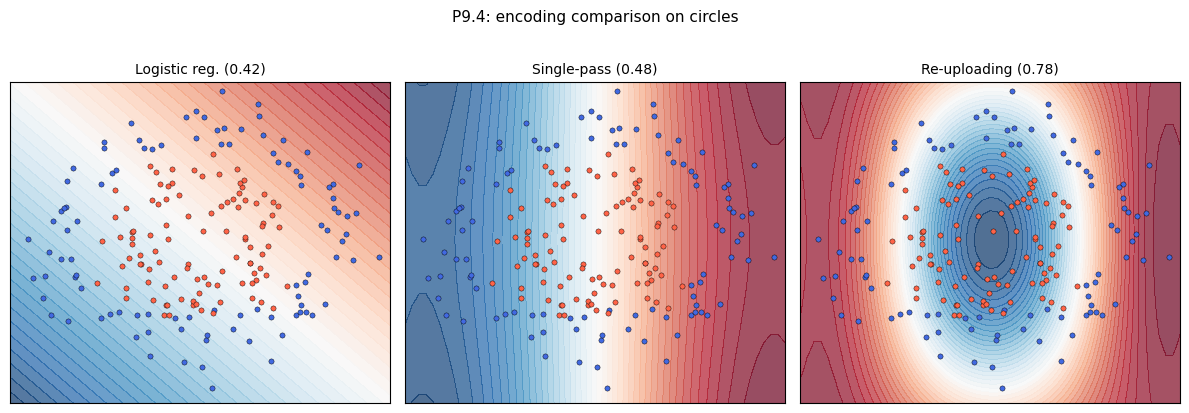

In [9]:
def plot_db(model_fn, X, y, ax, title, is_torch=True):
    h = 0.02
    xx, yy = np.meshgrid(
        np.arange(X[:,0].min()-0.05, X[:,0].max()+0.05, h),
        np.arange(X[:,1].min()-0.05, X[:,1].max()+0.05, h),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    if is_torch:
        with torch.no_grad():
            Z = model_fn(torch.tensor(grid, dtype=torch.float32)).squeeze().numpy()
    else:
        Z = model_fn(grid)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.7)
    ax.scatter(*X[y==0].T, s=14, c="royalblue", edgecolors="k", linewidths=0.3)
    ax.scatter(*X[y==1].T, s=14, c="tomato",    edgecolors="k", linewidths=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_db(
    lambda x: torch.tensor(lr_circ.predict_proba(x.numpy())[:, 1], dtype=torch.float32),
    X_circ, y_circ, axes[0], f"Logistic reg. ({acc_lr_c:.2f})"
)
plot_db(m_single,   X_circ, y_circ, axes[1], f"Single-pass ({acc_s:.2f})")
plot_db(m_reupload, X_circ, y_circ, axes[2], f"Re-uploading ({acc_r:.2f})")
plt.suptitle("P9.4: encoding comparison on circles", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### P9.5. Gradient norm at initialization: depth experiment

For a 4-qubit `StronglyEntanglingLayers` circuit, compute the mean gradient norm
at random initialization for $L \in \{1, 2, 4, 6\}$ layers.
Plot the result and comment on the trend.

L=1  mean=0.09008  std=0.02829


L=2  mean=0.08635  std=0.02462


L=4  mean=0.20771  std=0.03727


L=6  mean=0.21069  std=0.02530


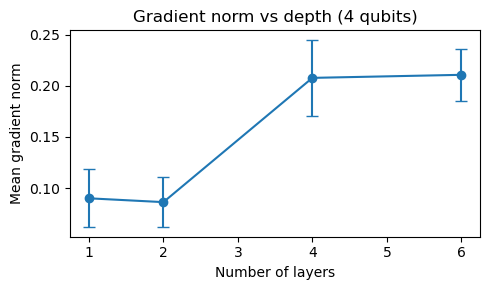

In [10]:
def mean_grad_norm(n_qubits, n_layers, n_trials=30):
    """Estimate mean gradient norm over random initializations."""
    dev_l = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev_l, interface="torch", diff_method="backprop")
    def circ(inputs, weights):
        qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return qml.expval(qml.PauliZ(0))

    shapes = {"weights": (n_layers, n_qubits, 3)}
    norms = []
    x_fixed = torch.rand(8, n_qubits)
    y_fixed  = torch.randint(0, 2, (8,)).float()

    for _ in range(n_trials):
        layer = qml.qnn.TorchLayer(circ, shapes)
        model_tmp = nn.Sequential(layer, nn.Sigmoid())
        loss = nn.BCELoss()(model_tmp(x_fixed).squeeze(), y_fixed)
        loss.backward()
        total = sum(
            p.grad.norm().item() ** 2
            for p in model_tmp.parameters() if p.grad is not None
        ) ** 0.5
        norms.append(total)
        model_tmp.zero_grad()

    return np.mean(norms), np.std(norms)


layers_list = [1, 2, 4, 6]
means, stds = [], []
for L in layers_list:
    m, s = mean_grad_norm(n_qubits=4, n_layers=L, n_trials=30)
    means.append(m)
    stds.append(s)
    print(f"L={L}  mean={m:.5f}  std={s:.5f}")

plt.figure(figsize=(5, 3))
plt.errorbar(layers_list, means, yerr=stds, marker="o", capsize=4)
plt.xlabel("Number of layers")
plt.ylabel("Mean gradient norm")
plt.title("Gradient norm vs depth (4 qubits)")
plt.tight_layout()
plt.show()

### P9.6 (optional). ZZ entangling encoding vs product encoding on circles

Build two 2-qubit models:

1. **Product model**: `AngleEmbedding(Y) + BasicEntanglerLayers(2)`
2. **ZZ model**: Hadamard layer, $R_z(2x_i)$ per qubit, CX + $R_z(2x_1 x_2)$, then `BasicEntanglerLayers(2)`

Train both on circles and compare test accuracy. The ZZ model encodes the pairwise
interaction $x_1 x_2$ as a phase, which should be more expressive for circular boundaries.

Product encoding acc: 0.480
ZZ encoding acc:      0.540


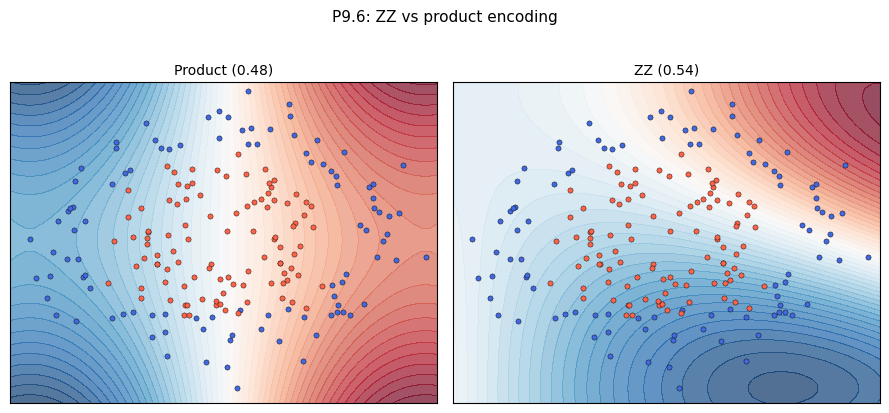

In [11]:
@qml.qnode(dev, interface="torch", diff_method="backprop")
def circuit_zz_p6(inputs, weights):
    """ZZ entangling encoding + BasicEntanglerLayers."""
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for i in range(n_qubits):
        qml.RZ(2.0 * inputs[..., i], wires=i)
    qml.CNOT(wires=[0, 1])
    qml.RZ(2.0 * inputs[..., 0] * inputs[..., 1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))


ql_prod_p6 = qml.qnn.TorchLayer(
    circuit_single_p4, {"weights": (2, n_qubits)}
)
ql_zz_p6 = qml.qnn.TorchLayer(
    circuit_zz_p6, {"weights": (2, n_qubits)}
)

m_prod_p6 = nn.Sequential(ql_prod_p6, nn.Sigmoid())
m_zz_p6   = nn.Sequential(ql_zz_p6,  nn.Sigmoid())

train_binary(m_prod_p6, Xct, yct, n_epochs=80, lr=0.02)
train_binary(m_zz_p6,   Xct, yct, n_epochs=80, lr=0.02)

with torch.no_grad():
    acc_prod_p6 = accuracy_score(y_cte, (m_prod_p6(Xcte).squeeze().numpy() >= 0.5))
    acc_zz_p6   = accuracy_score(y_cte, (m_zz_p6(Xcte).squeeze().numpy()   >= 0.5))

print(f"Product encoding acc: {acc_prod_p6:.3f}")
print(f"ZZ encoding acc:      {acc_zz_p6:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_db(m_prod_p6, X_circ, y_circ, axes[0], f"Product ({acc_prod_p6:.2f})")
plot_db(m_zz_p6,   X_circ, y_circ, axes[1], f"ZZ ({acc_zz_p6:.2f})")
plt.suptitle("P9.6: ZZ vs product encoding", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary

A hybrid QNN wraps a PQC inside a standard differentiable computational graph.
The main design decisions are:

- which encoding circuit to use (product angle, ZZ, re-uploading)
- how many classical layers to place before or after the quantum block
- how to measure (single observable vs multiple observables)

The parameter-shift rule provides exact gradients without finite differences,
and PennyLane's `diff_method='backprop'` provides the same result more efficiently
in simulation. Re-uploading and entangling encodings expand the function class
accessible to the model, which matters for non-linearly separable data. A logistic
regression baseline is always the first comparison point: a hybrid model that
underperforms it has a training or encoding issue, not an expressibility issue.